In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/phishing_site_urls.csv')

In [ ]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [ ]:
df.shape

(549346, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [ ]:
df.isnull().sum()

,0
URL,0
Label,0


In [ ]:
df.Label.value_counts()

,count
Label,
good,392924
bad,156422


In [ ]:
from nltk.tokenize import RegexpTokenizer

In [ ]:
tokenizer = RegexpTokenizer(r'[A-Za-z]+')

In [ ]:
df.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [ ]:
tokenizer.tokenize(df.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [ ]:
df['text_tokenized'] = df.URL.map(lambda t: tokenizer.tokenize(t))

In [ ]:
df.head()

,URL,Label,text_tokenized
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi..."


In [ ]:
from nltk.stem.snowball import SnowballStemmer

In [ ]:
stemmer = SnowballStemmer('english')

In [ ]:
df['text_stemmed'] = df['text_tokenized'].map(lambda l: [stemmer.stem(word) for word in l])

In [ ]:
df.head()

,URL,Label,text_tokenized,text_stemmed
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [ ]:
df['text'] = df['text_stemmed'].map(lambda l :' '.join(l))

In [ ]:
df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [ ]:
good_sites = df[df.Label == 'good']
bad_sites = df[df.Label == 'bad']

In [ ]:
good_sites.head()

,URL,Label,text_tokenized,text_stemmed,text
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...


In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def generate_word_cloud(text, title="Word Cloud", max_words=100, background_color="white", width=800, height=400):
    """
    Generates and displays a word cloud from the given text.

    Args:
        text (str): The input text to generate the word cloud from.
        title (str, optional): The title of the word cloud plot. Defaults to "Word Cloud".
        max_words (int, optional): The maximum number of words to display. Defaults to 100.
        background_color (str, optional): The background color of the word cloud. Defaults to "white".
        width (int, optional): The width of the word cloud image. Defaults to 800.
        height (int, optional): The height of the word cloud image. Defaults to 400.
    """
    wordcloud = WordCloud(
        max_words=max_words,
        background_color=background_color,
        width=width,
        height=height
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()


In [ ]:
all_text = ' '.join(good_sites['text'].tolist())

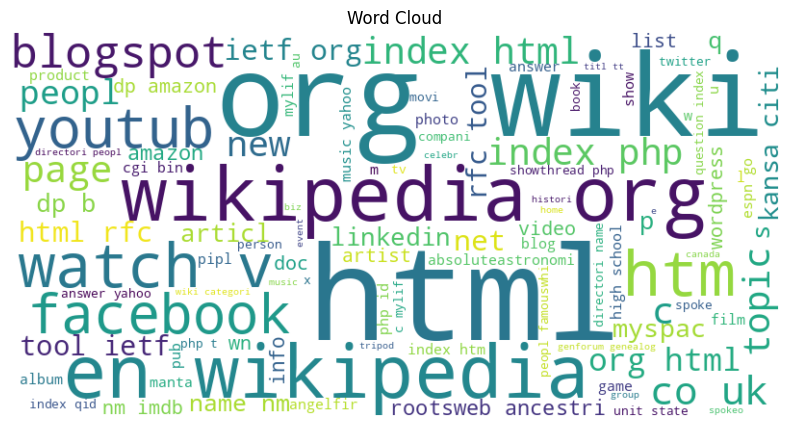

In [ ]:
generate_word_cloud(all_text)

In [ ]:
all_text = ' '.join(bad_sites['text'].tolist())

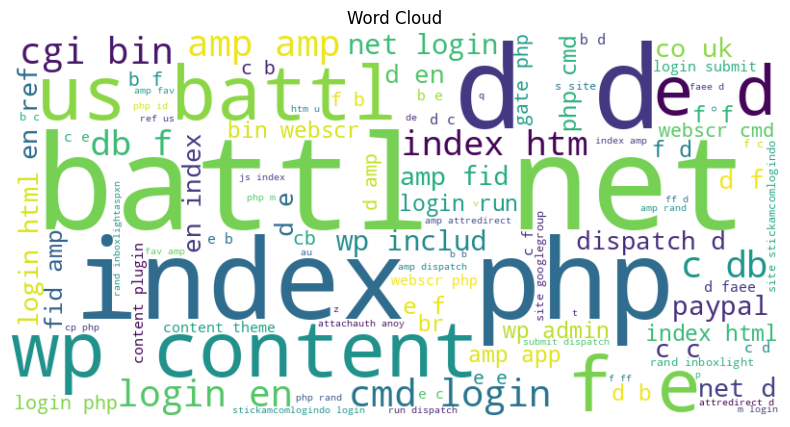

In [ ]:
generate_word_cloud(all_text)

In [ ]:
df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
features = cv.fit_transform(df.text)

In [ ]:
features[:5]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 77 stored elements and shape (5, 350837)>

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(features, df.Label, test_size=0.2)

##MODEL TRAINING

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
l_model = LogisticRegression()

In [ ]:
l_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
l_model.score(x_test, y_test)

0.9644397924820242

In [ ]:
l_model.score(x_train, y_train)

0.9785198736677315

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print('\n CLASSIFICATION REPORT \n')
print(classification_report(l_model.predict(x_test), y_test, target_names = ['Bad', 'Good']))


 CLASSIFICATION REPORT 

              precision    recall  f1-score   support

         Bad       0.91      0.97      0.94     29467
        Good       0.99      0.96      0.98     80403

    accuracy                           0.96    109870
   macro avg       0.95      0.96      0.96    109870
weighted avg       0.97      0.96      0.96    109870



In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
con_mat = pd.DataFrame(confusion_matrix(l_model.predict(x_test), y_test),
                       columns = ['Predicted: Bad', 'Predicted: Good'],
                       index = ['Actual: Bad', 'Actual: Good'])

In [ ]:
import seaborn as sns


 CONFUSION MATRIX 



<Axes: >

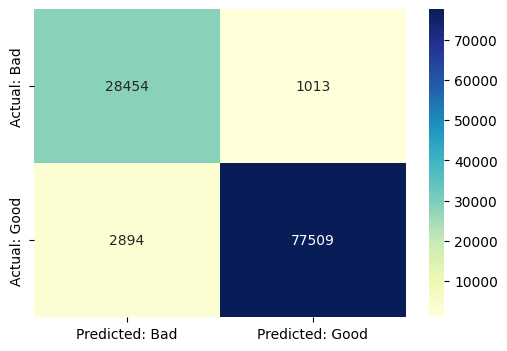

In [ ]:
print('\n CONFUSION MATRIX \n')
plt.figure(figsize = (6,4))
sns.heatmap(con_mat, annot = True, fmt = 'd', cmap = "YlGnBu")

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

Now that the labels are encoded, let's train the XGBoost model using the numerical labels.

In [ ]:
from xgboost import XGBClassifier

xg_model = XGBClassifier(n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
xg_model.fit(x_train, y_train_encoded)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:29:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
print(f'XGBoost training score: {xg_model.score(x_train, y_train_encoded):.4f}')
print(f'XGBoost test score: {xg_model.score(x_test, y_test_encoded):.4f}')

XGBoost training score: 0.9138
XGBoost test score: 0.9143


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Note: xg_model.predict will output 0s and 1s, so we compare with y_test_encoded
print('\n CLASSIFICATION REPORT \n')
print(classification_report(xg_model.predict(x_test), y_test_encoded, target_names = le.classes_))


 CLASSIFICATION REPORT 

              precision    recall  f1-score   support

         bad       0.75      0.94      0.83     25103
        good       0.98      0.91      0.94     84767

    accuracy                           0.91    109870
   macro avg       0.86      0.92      0.89    109870
weighted avg       0.93      0.91      0.92    109870




 CONFUSION MATRIX 



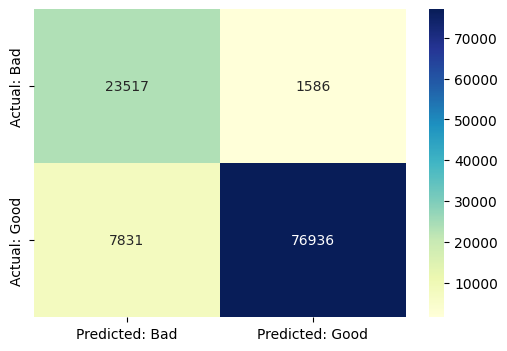

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

con_mat_xg = pd.DataFrame(confusion_matrix(xg_model.predict(x_test), y_test_encoded),
                       columns = ['Predicted: Bad', 'Predicted: Good'],
                       index = ['Actual: Bad', 'Actual: Good'])

print('\n CONFUSION MATRIX \n')
plt.figure(figsize = (6,4))
sns.heatmap(con_mat_xg, annot = True, fmt = 'd', cmap = "YlGnBu")
plt.show()

##SAVE MODEL

In [ ]:
import pickle

In [ ]:
pickle.dump(l_model, open('phishing.pkl', 'wb'))

In [ ]:
pickle.dump(cv, open('vectorizer.pkl', 'wb'))

In [ ]:
pickle.dump(le, open('encoder.pkl', 'wb'))

In [ ]:
pickle.dump(xg_model, open('xgb_model.pkl', 'wb'))

##sample test

In [ ]:
predict_bad = ['optimistic-pessimism.com/aoluserupdatealert.info.htm']

In [ ]:
predict_good = ['optimistic-pessimism.com/aoluserupdatealert.info.htm']

In [ ]:

predict_good = cv.transform(predict_good)

In [ ]:
predict_bad = cv.transform(predict_bad)

In [ ]:
l_model.predict(predict_good)

array(['good'], dtype=object)

In [ ]:
l_model.predict(predict_bad)

array(['good'], dtype=object)

### Making Predictions with XGBoost (Regenerated)

In [80]:
processed_urls = ['optimistic-pessimism.com/aoluserupdatealert.info.htm']

In [81]:
# Transform the processed URLs into features using the loaded CountVectorizer
new_urls_features = cv.transform(processed_urls)

print(f"Shape of new URL features: {new_urls_features.shape}")

Shape of new URL features: (1, 350837)


In [82]:
# Make predictions using the loaded XGBoost model
xg_predictions = xg_model.predict(new_urls_features)

print(f"Numerical predictions: {xg_predictions}")

Numerical predictions: [1]


In [83]:
# Inverse transform the numerical predictions back to original labels using the loaded LabelEncoder
xg_predicted_labels = le.inverse_transform(xg_predictions)

print(f"Predicted labels for new URLs: {xg_predicted_labels}")

print(f"\nPrediction for '{processed_urls}': {xg_predicted_labels}")


Predicted labels for new URLs: ['good']

Prediction for '['optimistic-pessimism.com/aoluserupdatealert.info.htm']': ['good']
